# Final Project

In [1]:
import parse_data as p_d
import descriptive as de
import matplotlib.pyplot as plt
import classical as cl
import machine as ml
df_small = p_d.df
df_full  = p_d.df_full

## Overview

This report analyzes the student-mat dataset to understand factors related to final grades (G3) and construct a simple predictive model. First, we summarize the distribution and basic statistics of key variables. Next, we test two target hypotheses. Finally, we compare a baseline model with an improved machine learning model using training/test validation.

## Descriptive statistics

<center><span style="font-size: 1.2em;"><b>Figure 1</b>: Distribution of final grade (G3)</span></center><br><br>

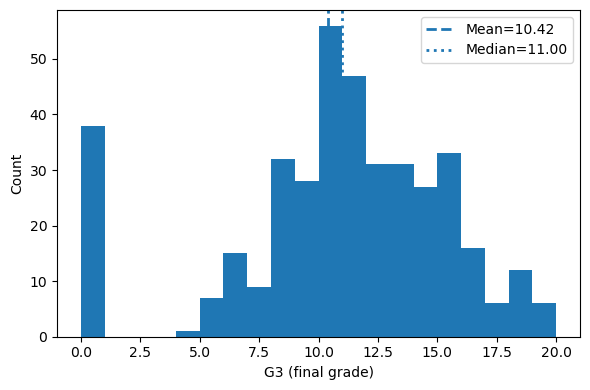

<br><br><p><span style="font-size: 1.2em;"><b>Table 1</b>: Summary statistics of studytime, absences, G1, and G3</span></p>

,mean,std,min,max,median
studytime,2.035443,0.839240,1,4,2.0
absences,5.708861,8.003096,0,75,4.0
G1,10.908861,3.319195,3,19,11.0
G3,10.415190,4.581443,0,20,11.0


In [2]:
fig, ax = de.fig_g3_distribution(df_small, bins=20)
plt.show()

tbl1 = de.summary_table(df_small)
display(tbl1)

Fig.1: Distribution of final grade (G3)
G3 is concentrated around 11.00, with a spread of 4.58. The mean (10.42) is slightly below the median (11.00), suggesting mild left-skew. This provides a baseline picture of overall performance before testing hypotheses.

Table 1: Summary statistics of studytime, absences, G1, and G3
Absences shows larger variability than studytime, while G1 and G3 are on similar scales. These patterns motivate focusing on G1 and absences in the hypothesis tests.

## Hypothesis testing

<center><span style="font-size: 1.2em;"><b>Figure 2</b>: Relationship between G1 and G3 (scatter with fitted regression line)</span></center><br><br>

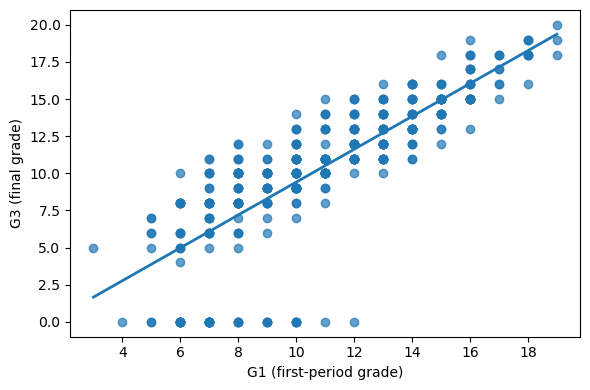

H1: r=0.801, p=9e-90, beta=1.106, R2=0.642


<center><span style="font-size: 1.2em;"><b>Figure 3</b>: Absences vs G3 by performance group, with interaction model fit (threshold = 10)</span></center><br><br>

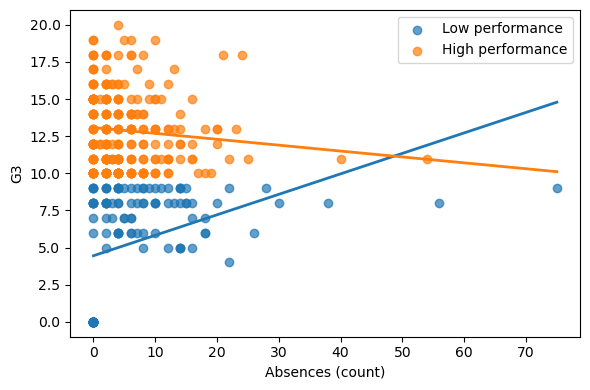

H2: r_high=-0.102, r_low=0.396, beta_interaction=-0.178, p_interaction=1.1e-06, R2=0.628


In [3]:
h1, fig2 = cl.run_h1(df_small)
plt.show(fig2)
print(f"H1: r={h1['r']:.3f}, p={h1['p']:.2g}, beta={h1['coef_G1']:.3f}, R2={h1['r2']:.3f}")

h2, fig3 = cl.run_h2(df_small, threshold=10)
plt.show(fig3)
print(f"H2: r_high={h2['r_high']:.3f}, r_low={h2['r_low']:.3f}, beta_interaction={h2['coef_interaction']:.3f}, p_interaction={h2['p_interaction']:.2g}, R2={h2['r2']:.3f}")

Fig.2: Relationship between G1 and G3 (scatter with fitted regression line).
G1 and G3 show a positive association (r = 0.801, p = 9e-90). A simple regression indicates that a one-point increase in G1 is associated with approximately 1.106 points higher G3 (β = 1.106), with R² = 0.642. This suggests earlier performance is strongly informative for final performance, although this is correlational rather than causal.

Fig.3: Absences vs G3 by performance group, with interaction model fit (threshold = 10).
The relationship between absences and G3 differs across groups (interaction term p = 1.1e-06). In the high-performance group, the correlation is -0.102, while in the low-performance group it is 0.396. This indicates that absences may be more strongly linked to outcomes for　low-performing students, but the pattern should be interpreted cautiously due to group sizes and observational data. Because groups are defined by G3 itself and the data are observational, within-group correlations can be distorted and should not be interpreted causally.

## Machine learning

<center><span style="font-size: 1.2em;"><b>Figure 4</b>: Predicted vs actual G3 for the best regression model (test set)</span></center><br><br>

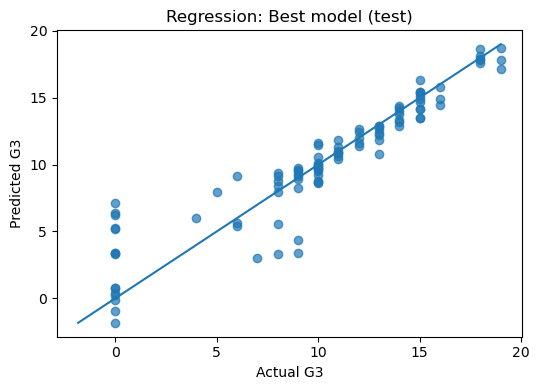

<center><span style="font-size: 1.2em;"><b>Figure 5</b>: Confusion matrix of the best classification model (test set).</span></center><br><br>

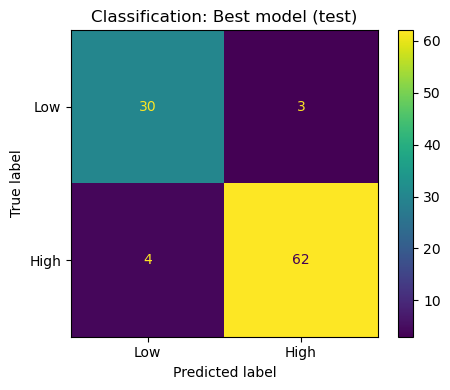

In [4]:
reg_tbl, reg_fig = ml.final_regression_result(df_small, df_full)
plt.show(reg_fig)

clf_tbl, clf_fig = ml.final_classification_result(df_small, df_full, threshold=10)
plt.show(clf_fig)

Fig.4: Predicted vs actual G3 for the best regression model (test set).
On the test set, the best regression model achieves R² = 0.860 and RMSE = 1.99, improving over the baseline (R² = -0.007, RMSE = 5.34). The plot shows predictions are generally close to the diagonal, with larger errors mainly at very low scores.

Fig.5: Confusion matrix of the best classification model (test set).
On the test set, the best classifier achieves F1 = 0.947 and Accuracy = 0.929, outperforming the baseline (F1 = 0.800). Most errors are false negatives (high predicted as low), suggesting the model mainly struggles with borderline cases near the threshold.

## Summary

- G3 has moderate spread; mean and median indicate 10.42 and 11.00
- G1 is strongly associated with G3 (r = 0.801, regression R² = 0.642)
- Absences shows group-dependent relationship with G3 (interaction p = 1.1e-06)
- Best ML models outperform baselines for both regression and classification
- Limitation: observational data; results are correlational; single dataset
- Next: try cross-validation / alternative models / feature engineering